# Contrast model overlap: ΔS(N=8−N=4) vs. gradient / filtered length

For a chosen dataset (brain or phantom), subject, ROI, direction and diffusion time `td`,
this notebook overlays the four competing OGSE diffusion models on top of the *resampled*
contrast ΔS = S(N=8) − S(N=4) (each branch's own raw signal is independently fit and the two
fitted curves are evaluated on one common gradient grid and subtracted -- see section 4):

- **free** — unrestricted (Gaussian) diffusion, `D0` fixed.
- **rest** — restriction inside impermeable compartments (Callaghan), fits a correlation
  time `tc`.
- **tort** — macroscopic tortuosity rescaling of `D0` (fits `alpha = D/D0`).
- **mixed** — two-population mixture of `tort`-scaled free diffusion and `rest`-restricted
  diffusion, fits `tc` and `alpha` jointly.

This reproduces the "contrast fits" figure from the research script
`research/notebooks-portable/fit_ogse_mixed_mixed.ipynb`, but runs on the project's real
`master.long.parquet` tables (brains and phantoms) via the existing `presentation_analysis`
loading and resampling helpers (`build_resampled_contrasts`, the same routine behind
`06_all_signal_contrast_panels`), and keeps every plotting/fitting detail editable in this
notebook rather than in a `.py` module.

Edit the **QUICK SELECTION** cell to choose dataset/subject/ROI/direction/td and which
models to overlay, and the **figure style** block in the same cell to change figure size,
font sizes, colors, and marker sizes. The **preview** section renders one figure inline;
the **batch export** section saves every remaining combination to `notebooks/outputs/`.


## 1. Imports

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import least_squares


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'Data-BIDS').is_dir() and (candidate / 'repos' / 'signal_analysis').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the Project-Balseiro-Microstructure root.')


PROJECT_ROOT = find_project_root()
REPO_ROOT = PROJECT_ROOT / 'repos' / 'signal_analysis'
SRC_ROOT = REPO_ROOT / 'src'
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from presentation_analysis import (
    CC_ROIS,
    DEFAULT_DIRECTIONS,
    discover_analysis_runs,
    load_masters,
    save_figure_formats,
)
from presentation_analysis.abstract_figures import GAMMA_RAD_MS_MT, build_resampled_contrasts
from models.model_fitting import (
    OGSE_contrast_vs_g_free,
    OGSE_contrast_vs_g_mixed,
    OGSE_contrast_vs_g_rest,
    OGSE_contrast_vs_g_tort,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_rows', 120)
pd.set_option('display.max_columns', 80)
PROJECT_ROOT


PosixPath('/mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure')

## 2. Quick selection

Edit this block, then re-run from here down (or `Kernel > Restart & Run All`).


In [2]:
# -----------------------------------------------------------------------------
# QUICK SELECTION: edit this block first.
# -----------------------------------------------------------------------------
DATASET = 'brains'                # 'brains' or 'phantoms'

# Examples: ['ADBN'], ['ADBN', 'ARVE'], or None for all subjects
SUBJECTS_OVERRIDE = None
SHEETS_OVERRIDE = None            # e.g. ['20230623_BRAIN-4'], useful for repeated scans

# None -> dataset default (see DATASET_PROFILES below)
ROI_OVERRIDE = None               # brain e.g. ['AntCC', 'PostCC']; phantom e.g. ['fiber1']
DIRECTION_OVERRIDE = None         # None -> ['tra', 'long']
TD_OVERRIDE = None                # e.g. [143.4] to keep a single diffusion time, or None for all

# Segmentation to use (this is the "variant" folder suffix in Data-BIDS, e.g.
# den_gr-topup--plain / --erode1 / --sket1). IMPORTANT: leaving this as None does NOT
# mean "use the dataset default" for every subject on disk -- Data-BIDS holds one
# master.long.parquet per segmentation, and mixing them merges independent
# re-segmentations of the same acquisition into one scatter/fit, which inflates the
# point count and drags every fit off. Always pick exactly one segmentation unless you
# deliberately want several plotted side by side (each still fit/plotted separately).
# brains: 'plain' (default), 'erode1', 'sket1'. phantoms: 'manual' (only option).
SEGMENTATION_OVERRIDE = 'plain'

# Which models to overlay -- trim this list freely, order sets legend/draw order
MODELS_TO_PLOT = ['free', 'rest', 'tort', 'mixed']

# How 'tort'/'mixed' get their alpha (D = alpha * D0). 'fit' fits alpha freely against
# this ROI's own contrast curve (the tc/alpha grid-search fit below). 'alpha_macro' fixes
# alpha instead to the 'alpha_macro' column already stored per (subj, roi, direction, td)
# in the master table (typically a PGSE-derived macroscopic tortuosity estimate) -- 'tort'
# then has nothing left to fit (pure evaluation, like 'free'), and 'mixed' still fits `tc`
# alone with alpha held fixed. Does not affect 'free'/'rest' (neither has an alpha).
ALPHA_MODE = 'alpha_macro'                # 'fit' or 'alpha_macro'

# Contrast definition: ΔS = S(N_HIGH) - S(N_LOW)
N_HIGH, N_LOW = 8, 4
GRADIENT_COLUMN = 'g'
APPLY_GRADIENT_CORRECTION = True

X_AXIS = 'lcf'                      # 'g' (gradient, mT/m) or 'lcf' (filtered length, um)
LCF_XLIM_UM = (2.5, 11.0)         # only applied when X_AXIS == 'lcf'; None disables the limit

# Resampling: each branch (N_HIGH, N_LOW) is fit on its own with a single-population
# rest+Rician-floor signal model (build_resampled_contrasts, same routine used by
# esmrmb_variant_comparison.ipynb / 06_all_signal_contrast_panels), then both fitted
# branches are evaluated on one common gradient grid and subtracted. That resampled
# difference -- not a b-step-paired raw difference -- is the "observed contrast" the four
# candidate models below are fit against, and is drawn as the gray reference curve.
RESAMPLE_GRID_SIZE = 400          # points on the common resampled gradient grid
SIGNAL_TC_BOUNDS_MS = (0.1, 10000.0)   # bounds for the per-branch rest_offset signal fit
RICIAN_C_BOUNDS = (0.0, 2.0)
SIGNAL_TC_MODE = 'separate'       # 'separate' or 'shared' tc between the two branches

# Dataset profiles: acquisition physics and default ROI/direction selections.
DATASET_PROFILES = {
    'brains': {
        'dwi_level': 'den_gr-topup',
        'segmentation': 'plain',
        'd0_m2_ms': 3.2e-12,
        'rois': list(CC_ROIS),
        'directions': list(DEFAULT_DIRECTIONS),
    },
    'phantoms': {
        'dwi_level': 'den_gr-topup',
        'segmentation': 'manual',
        'd0_m2_ms': 2.3e-12,
        'rois': None,
        'directions': None,
    },
}

# ---- Per-model fit configuration: bounds, all editable ----
# `tc` spans several orders of magnitude and the rest/mixed residual landscape is NOT
# always unimodal in tc (a "hump" can separate a spurious near-zero-tc minimum from the
# real optimum at large tc) -- a single fixed initial guess can get trapped on the wrong
# side of that hump. So instead of one INIT value, every tc/alpha fit below first scans a
# log/linear grid across its bounds, keeps the best-scoring grid point as the starting
# point, and only then refines it with least_squares. GRID_POINTS controls how fine that
# scan is (more points = more robust against local minima, slower).
REST_TC_BOUNDS_MS = (0.05, 1000.0)
REST_TC_GRID_POINTS = 40
TORT_ALPHA_BOUNDS = (0.0, 1.0)
TORT_ALPHA_GRID_POINTS = 21
MIXED_TC_BOUNDS_MS = (0.05, 1000.0)
MIXED_ALPHA_BOUNDS = (0.0, 1.0)
MIXED_TC_GRID_POINTS = 25
MIXED_ALPHA_GRID_POINTS = 11

# -----------------------------------------------------------------------------
# Figure style -- edit freely, then re-run the preview cell.
# -----------------------------------------------------------------------------
FIGSIZE_PER_PANEL = (4.5, 4.0)     # (width, height) inches, per direction column
DPI_SAVE = 150
FONTSIZE_SUPTITLE = 10
FONTSIZE_TITLE = 9
FONTSIZE_AXIS_LABEL = 10
FONTSIZE_TICK = 9
FONTSIZE_LEGEND = 7
MODEL_COLORS = {'free': 'C0', 'rest': 'C1', 'tort': 'C2', 'mixed': 'C3'}
MARKER_SIZE_HIGH = 20              # filled dots, N_HIGH's own real G positions
MARKER_SIZE_LOW = 60               # open circles, N_LOW's own real G positions
LINEWIDTH = 1.5
RESAMPLED_LINE_COLOR = '#bbbbbb'   # gray reference curve (the resampled contrast itself)
RESAMPLED_LINEWIDTH = 2.5

SAVE_OUTPUTS = True

# -----------------------------------------------------------------------------
def selection_list(value):
    if value is None:
        return None
    return [value] if isinstance(value, str) else list(value)


SELECTED_SUBJECTS = selection_list(SUBJECTS_OVERRIDE)
SELECTED_SHEETS = selection_list(SHEETS_OVERRIDE)
SELECTED_TDS = selection_list(TD_OVERRIDE)
if DATASET not in DATASET_PROFILES:
    raise ValueError(f'Unknown DATASET={DATASET!r}; choose one of {list(DATASET_PROFILES)}.')
PROFILE = DATASET_PROFILES[DATASET]
DWI_LEVEL = PROFILE['dwi_level']
D0_M2_MS = PROFILE['d0_m2_ms']
SELECTED_ROIS = selection_list(ROI_OVERRIDE) or PROFILE['rois']
SELECTED_DIRECTIONS = selection_list(DIRECTION_OVERRIDE) or PROFILE['directions'] or list(DEFAULT_DIRECTIONS)
SELECTED_SEGMENTATIONS = selection_list(SEGMENTATION_OVERRIDE) or [PROFILE['segmentation']]

for model in MODELS_TO_PLOT:
    if model not in MODEL_COLORS:
        raise ValueError(f'Unknown model {model!r}; choose from {list(MODEL_COLORS)}.')
if ALPHA_MODE not in ('fit', 'alpha_macro'):
    raise ValueError(f"Unknown ALPHA_MODE={ALPHA_MODE!r}; choose 'fit' or 'alpha_macro'.")

OUTPUT_DIR = (
    REPO_ROOT / 'notebooks' / 'outputs' / 'contrast_models_overlap' / 'resample-ogse_rest_rician'
    / DATASET / DWI_LEVEL / SEGMENTATION_OVERRIDE / X_AXIS / ('alpha_fit' if ALPHA_MODE == 'fit' else 'alpha_macro')
)
OUTPUT_DIR


PosixPath('/mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/contrast_models_overlap/resample-ogse_rest_rician/brains/den_gr-topup/plain/lcf/alpha_macro')

## 3. Load data

`discover_analysis_runs(..., dwi_level=DWI_LEVEL)` matches every segmentation variant
stored under that `dwi_level` (e.g. `den_gr-topup--plain`, `--erode1`, `--sket1` all share
`dwi_level='den_gr-topup'` -- the segmentation is the part after `--`). We therefore always
pass an explicit `variants=SELECTED_SEGMENTATIONS` to `load_masters` below so exactly one
segmentation is loaded by default, instead of silently concatenating all of them.


In [3]:
runs = discover_analysis_runs(PROJECT_ROOT, dataset=DATASET, dwi_level=DWI_LEVEL)
print(f'Available segmentations for {DATASET}/{DWI_LEVEL}: {sorted(runs["variant"].unique())}')

masters = load_masters(runs, variants=SELECTED_SEGMENTATIONS)

if SELECTED_SUBJECTS is not None:
    masters = masters[masters['subj'].astype(str).isin(SELECTED_SUBJECTS)]
if SELECTED_SHEETS is not None:
    masters = masters[masters['sheet'].astype(str).isin(SELECTED_SHEETS)]
if masters.empty:
    raise ValueError('No rows left after subject/sheet filtering -- check SUBJECTS_OVERRIDE/SHEETS_OVERRIDE.')

print(f'Using segmentation(s): {sorted(masters["variant"].unique())}')
print(f'{DATASET} / {DWI_LEVEL}: {masters["subj"].nunique()} subject(s), '
      f'{masters["roi"].nunique()} ROI(s), {masters["td_ms"].nunique()} diffusion time(s)')

_sheets_per_subject = masters.groupby('subj')['sheet'].nunique()
_multi_sheet_subjects = sorted(_sheets_per_subject[_sheets_per_subject > 1].index)
if _multi_sheet_subjects:
    print(f'Note: these subjects have more than one sheet (scan session) in this selection '
          f'-- each is fit and plotted separately, never pooled: {_multi_sheet_subjects}')

_signal_rows = masters[masters['row_kind'] == 'signal_rotated']

# One alpha_macro value per (segmentation, subj, sheet, roi, direction, td) group, used
# below when ALPHA_MODE == 'alpha_macro' to fix 'tort'/'mixed' instead of fitting alpha.
alpha_macro_lookup = (
    _signal_rows
    .groupby(['variant', 'subj', 'sheet', 'roi', 'direction', 'td_ms'])['alpha_macro']
    .first()
    .to_dict()
)

# Each branch's own real gradient-corrected G values, per (segmentation, subj, sheet, roi,
# direction, td, N) -- used to place the filled/open markers on the resampled contrast
# curve at exactly the G positions where that branch actually has measurements.
def _corrected_g(frame):
    g_raw = pd.to_numeric(frame[GRADIENT_COLUMN], errors='coerce').to_numpy(float)
    if APPLY_GRADIENT_CORRECTION:
        correction = pd.to_numeric(frame['grad_correction_factor'], errors='coerce').to_numpy(float)
    else:
        correction = np.ones(len(frame), dtype=float)
    g_corr = g_raw * correction
    return np.sort(g_corr[np.isfinite(g_corr)])


_avg_rows = _signal_rows[_signal_rows['stat'] == 'avg'].copy()
_avg_rows['N_int'] = pd.to_numeric(_avg_rows['N'], errors='coerce').astype('Int64')
raw_g_lookup = {
    (variant, subj, sheet, roi, direction, float(td_ms), int(n_value)): _corrected_g(group)
    for (variant, subj, sheet, roi, direction, td_ms, n_value), group in _avg_rows.groupby(
        ['variant', 'subj', 'sheet', 'roi', 'direction', 'td_ms', 'N_int'], sort=False, dropna=False
    )
}
sorted(masters['subj'].unique())


Available segmentations for brains/den_gr-topup: ['erode1', 'plain', 'sket1']
Using segmentation(s): ['plain']
brains / den_gr-topup: 6 subject(s), 8 ROI(s), 5 diffusion time(s)
Note: these subjects have more than one sheet (scan session) in this selection -- each is fit and plotted separately, never pooled: ['BRAIN', 'LUDG', 'MBBL']


['ADBN', 'ARVE', 'BRAIN', 'LUDG', 'MBBL', 'SNVN']

## 4. Resample the per-branch signal fits

`build_resampled_contrasts` fits a single-population rest+Rician-floor signal model
(`M_ogse_rest_rician`, shared floor `C`, `tc` per `SIGNAL_TC_MODE`) independently to each
branch's own raw, gradient-corrected data, then evaluates both fitted branches on one common
gradient grid and subtracts them -- this is the exact same routine behind
`signal_and_contrast_panels.ipynb`'s `06_all_signal_contrast_panels` gallery (left panel:
per-branch signal fits; right panel: the resulting "resampled contrast").

That resampled `contrast` -- not a b-step-paired raw difference -- is what the four candidate
models (`free`/`rest`/`tort`/`mixed`) are fit against below, and what gets drawn as the gray
reference curve. It groups by `variant, subj, sheet, roi, direction, td_ms` (note `sheet`:
repeat scan sessions are resampled/fit separately, never pooled together).


In [4]:
resampled, signal_fit_summary = build_resampled_contrasts(
    masters,
    d0_m2_ms=D0_M2_MS,
    n_high=N_HIGH,
    n_low=N_LOW,
    directions=SELECTED_DIRECTIONS,
    rois=SELECTED_ROIS,
    gradient_column=GRADIENT_COLUMN,
    apply_gradient_correction=APPLY_GRADIENT_CORRECTION,
    tc_bounds_ms=SIGNAL_TC_BOUNDS_MS,
    rician_c_bounds=RICIAN_C_BOUNDS,
    grid_size=RESAMPLE_GRID_SIZE,
    tc_mode=SIGNAL_TC_MODE,
)
if SELECTED_TDS is not None:
    resampled = resampled[resampled['td_ms'].isin(SELECTED_TDS)]
if resampled.empty:
    raise ValueError('No resampled contrast rows left -- check ROI_OVERRIDE/DIRECTION_OVERRIDE/TD_OVERRIDE.')

_failed = signal_fit_summary[~signal_fit_summary['ok']]
if len(_failed):
    print(f'Note: {len(_failed)} (subj, sheet, roi, direction, td) group(s) failed the '
          f'per-branch signal fit and have no resampled contrast -- see signal_fit_summary.')

print(f'{RESAMPLE_GRID_SIZE} resampled points per curve, across '
      f'{resampled.groupby(["variant", "subj", "sheet", "roi", "direction", "td_ms"]).ngroups} '
      f'(segmentation, subj, sheet, roi, direction, td) groups')
resampled.head()


400 resampled points per curve, across 250 (segmentation, subj, sheet, roi, direction, td) groups


,variant,subj,sheet,roi,direction,td_ms,grid_index,N_high,N_low,gradient_column,lcf_convention,g_resampled_corr,g_high_corr,g_low_corr,signal_high_fit,signal_low_fit,contrast,contrast_std,lcf_um,tau_f_axis_ms,tc_axis_ms
0,plain,ADBN,20260710_ADBN-1,AntCC,tra,90.0,0,8,4,g,capiglioni_2021,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,NaN,NaN,NaN,NaN
1,plain,ADBN,20260710_ADBN-1,AntCC,tra,90.0,1,8,4,g,capiglioni_2021,0.152666,0.152666,0.152666,0.999997,0.999990,0.000007,NaN,75.196794,1767.049313,1767.049313
2,plain,ADBN,20260710_ADBN-1,AntCC,tra,90.0,2,8,4,g,capiglioni_2021,0.305331,0.305331,0.305331,0.999988,0.999961,0.000027,NaN,53.172163,883.524656,883.524656
3,plain,ADBN,20260710_ADBN-1,AntCC,tra,90.0,3,8,4,g,capiglioni_2021,0.457997,0.457997,0.457997,0.999973,0.999913,0.000061,NaN,43.414889,589.016438,589.016438
4,plain,ADBN,20260710_ADBN-1,AntCC,tra,90.0,4,8,4,g,capiglioni_2021,0.610662,0.610662,0.610662,0.999952,0.999845,0.000108,NaN,37.598397,441.762328,441.762328


## 5. Model fitting

Each model is fit against the resampled `contrast` column from section 4, on the shared
`g_resampled_corr` grid (`G1=G2=g_resampled_corr` in `OGSE_contrast_vs_g_*(TE, G1, G2, N1,
N2, ...)`, since both branches already live on one common grid). `M0=1` and `D0` is fixed
from the dataset profile; only `tc` and/or `alpha` are free parameters. `free` has no free
parameters -- it is only evaluated, not fit.

**Why a grid search before `least_squares`:** the `rest`/`mixed` residual is not always
unimodal in `tc` -- for some (ROI, direction, td) groups there is a spurious, much worse
local minimum where `tc` collapses toward its lower bound (physically: the compartment
becomes so "small"/uncorrelated that essentially no diffusion attenuation is achievable at
any measured gradient, so the predicted contrast is flat at ~0), separated by a residual
"hump" from the true, much better optimum at large `tc` (which recovers the free-diffusion
limit, since `rest(tc→∞) → free`, *not* `tort`). A single fixed initial guess can
land on the wrong side of that hump and get trapped. So every fit below first scans a
log/linear grid across the parameter's bounds, keeps the best-scoring grid point as the
starting point for `least_squares`, and only then refines it -- this reliably finds the
global optimum without needing a per-group manual initial guess.

**`ALPHA_MODE`** (set in the quick-selection cell) controls where `tort`/`mixed` get their
`alpha`: `'fit'` fits it as above; `'alpha_macro'` fixes it instead to the `alpha_macro`
column already stored per (subj, roi, direction, td) in the master table, so `mixed` then
only fits `tc`. Figures fit this way get an `(α_macro)` tag next to `alpha` in the legend.


In [5]:
def _grid_1d(bounds, n, log):
    lo, hi = bounds
    grid = np.logspace(np.log10(lo), np.log10(hi), n) if log else np.linspace(lo, hi, n)
    grid[0], grid[-1] = lo, hi  # guard against log10/exp round-trip drifting past the bounds
    return grid


def _best_start(sse_fn, grids):
    """Evaluate sse_fn on the cartesian product of `grids` (1 or 2 of them) and
    return the grid point with the lowest SSE, for use as a least_squares x0.

    sse_fn must return a *scalar* SSE (see callers below): if any predicted point is
    non-finite (overflow at extreme tc), the caller returns np.inf rather than letting
    e.g. nansum silently score an all-NaN prediction as a perfect (zero) fit.
    """
    mesh = np.meshgrid(*grids, indexing='ij')
    with np.errstate(all='ignore'):
        sse = np.vectorize(sse_fn)(*mesh)
    sse = np.where(np.isfinite(sse), sse, np.inf)
    best_index = np.unravel_index(np.argmin(sse), sse.shape)
    return tuple(m[best_index] for m in mesh)


def _safe_sse(pred, y):
    """SSE that scores an out-of-range prediction (overflow -> nan/inf) as np.inf
    instead of silently treating an all-NaN curve as a perfect (zero) fit."""
    diff = np.asarray(pred, dtype=float) - y
    return float(np.sum(diff ** 2)) if np.all(np.isfinite(diff)) else np.inf


def _fit_rest(g_common, y, td_ms, d0_m2_ms):
    def sse(tc):
        pred = OGSE_contrast_vs_g_rest(td_ms, g_common, g_common, N_HIGH, N_LOW, tc, 1.0, d0_m2_ms)
        return _safe_sse(pred, y)

    (tc0,) = _best_start(sse, [_grid_1d(REST_TC_BOUNDS_MS, REST_TC_GRID_POINTS, log=True)])

    def residual(p):
        return OGSE_contrast_vs_g_rest(td_ms, g_common, g_common, N_HIGH, N_LOW, np.exp(p[0]), 1.0, d0_m2_ms) - y

    result = least_squares(
        residual, x0=[np.log(tc0)],
        bounds=([np.log(REST_TC_BOUNDS_MS[0])], [np.log(REST_TC_BOUNDS_MS[1])]),
        method='trf', max_nfev=10000,
    )
    return {'tc': float(np.exp(result.x[0]))}


def _fit_tort(g_common, y, td_ms, d0_m2_ms, alpha_fixed=None):
    if alpha_fixed is not None:
        return {'alpha': float(alpha_fixed), 'alpha_source': 'alpha_macro'}

    def sse(alpha):
        pred = OGSE_contrast_vs_g_tort(td_ms, g_common, g_common, N_HIGH, N_LOW, alpha, 1.0, d0_m2_ms)
        return _safe_sse(pred, y)

    (alpha0,) = _best_start(sse, [_grid_1d(TORT_ALPHA_BOUNDS, TORT_ALPHA_GRID_POINTS, log=False)])

    def residual(p):
        return OGSE_contrast_vs_g_tort(td_ms, g_common, g_common, N_HIGH, N_LOW, p[0], 1.0, d0_m2_ms) - y

    result = least_squares(
        residual, x0=[alpha0],
        bounds=([TORT_ALPHA_BOUNDS[0]], [TORT_ALPHA_BOUNDS[1]]),
        method='trf', max_nfev=10000,
    )
    return {'alpha': float(result.x[0]), 'alpha_source': 'fit'}


def _fit_mixed(g_common, y, td_ms, d0_m2_ms, alpha_fixed=None):
    if alpha_fixed is None:
        def sse(tc, alpha):
            pred = OGSE_contrast_vs_g_mixed(td_ms, g_common, g_common, N_HIGH, N_LOW, tc, alpha, 1.0, d0_m2_ms)
            return _safe_sse(pred, y)

        tc0, alpha0 = _best_start(
            sse,
            [
                _grid_1d(MIXED_TC_BOUNDS_MS, MIXED_TC_GRID_POINTS, log=True),
                _grid_1d(MIXED_ALPHA_BOUNDS, MIXED_ALPHA_GRID_POINTS, log=False),
            ],
        )

        def residual(p):
            return OGSE_contrast_vs_g_mixed(
                td_ms, g_common, g_common, N_HIGH, N_LOW, np.exp(p[0]), p[1], 1.0, d0_m2_ms
            ) - y

        result = least_squares(
            residual, x0=[np.log(tc0), alpha0],
            bounds=(
                [np.log(MIXED_TC_BOUNDS_MS[0]), MIXED_ALPHA_BOUNDS[0]],
                [np.log(MIXED_TC_BOUNDS_MS[1]), MIXED_ALPHA_BOUNDS[1]],
            ),
            method='trf', max_nfev=10000,
        )
        return {'tc': float(np.exp(result.x[0])), 'alpha': float(result.x[1]), 'alpha_source': 'fit'}

    # alpha fixed to alpha_macro -- only tc is free.
    alpha = float(alpha_fixed)

    def sse(tc):
        pred = OGSE_contrast_vs_g_mixed(td_ms, g_common, g_common, N_HIGH, N_LOW, tc, alpha, 1.0, d0_m2_ms)
        return _safe_sse(pred, y)

    (tc0,) = _best_start(sse, [_grid_1d(MIXED_TC_BOUNDS_MS, MIXED_TC_GRID_POINTS, log=True)])

    def residual(p):
        return OGSE_contrast_vs_g_mixed(td_ms, g_common, g_common, N_HIGH, N_LOW, np.exp(p[0]), alpha, 1.0, d0_m2_ms) - y

    result = least_squares(
        residual, x0=[np.log(tc0)],
        bounds=([np.log(MIXED_TC_BOUNDS_MS[0])], [np.log(MIXED_TC_BOUNDS_MS[1])]),
        method='trf', max_nfev=10000,
    )
    return {'tc': float(np.exp(result.x[0])), 'alpha': alpha, 'alpha_source': 'alpha_macro'}


_MODEL_CURVE = {
    'free': lambda td, g, params, d0: OGSE_contrast_vs_g_free(td, g, g, N_HIGH, N_LOW, 1.0, d0),
    'rest': lambda td, g, params, d0: OGSE_contrast_vs_g_rest(td, g, g, N_HIGH, N_LOW, params['tc'], 1.0, d0),
    'tort': lambda td, g, params, d0: OGSE_contrast_vs_g_tort(td, g, g, N_HIGH, N_LOW, params['alpha'], 1.0, d0),
    'mixed': lambda td, g, params, d0: OGSE_contrast_vs_g_mixed(
        td, g, g, N_HIGH, N_LOW, params['tc'], params['alpha'], 1.0, d0
    ),
}
_MODEL_FITTERS = {'free': None, 'rest': _fit_rest, 'tort': _fit_tort, 'mixed': _fit_mixed}


def gradient_to_lcf_um(td_ms: float, g_mtm: np.ndarray, d0_m2_ms: float) -> np.ndarray:
    """Capiglioni et al., Phys. Rev. Applied 15, 014045 (2021)."""
    g_mtm = np.asarray(g_mtm, dtype=float)
    with np.errstate(divide='ignore', invalid='ignore'):
        length_g = (d0_m2_ms / (GAMMA_RAD_MS_MT * g_mtm)) ** (1.0 / 3.0)
        length_d = np.sqrt(d0_m2_ms * td_ms)
        length_cf = ((3.0 / 2.0) ** 0.25) * (length_d / length_g) ** (-0.5) * length_g
    return length_cf * 1e6


_ALPHA_MODELS = ('tort', 'mixed')


def fit_group(g_common: np.ndarray, y: np.ndarray, td_ms: float, d0_m2_ms: float,
              models: list[str], *, alpha_fixed: float | None = None) -> dict:
    entry = {'G_common': g_common, 'contrast': y, 'lcf_common': gradient_to_lcf_um(td_ms, g_common, d0_m2_ms)}
    for model in models:
        fitter = _MODEL_FITTERS[model]
        if fitter is None:
            params = {}
        elif model in _ALPHA_MODELS:
            params = fitter(g_common, y, td_ms, d0_m2_ms, alpha_fixed=alpha_fixed)
        else:
            params = fitter(g_common, y, td_ms, d0_m2_ms)
        curve = _MODEL_CURVE[model](td_ms, g_common, params, d0_m2_ms)
        entry[model] = {**params, 'C_curve': curve}
    return entry


fit_store: dict[tuple, dict] = {}
group_keys = ['variant', 'subj', 'sheet', 'roi', 'direction', 'td_ms']
missing_alpha_macro = 0
for key, group in resampled.groupby(group_keys, sort=False, dropna=False):
    variant, subj, sheet, roi, direction, td_ms = key
    g_common = group['g_resampled_corr'].to_numpy(float)
    y = group['contrast'].to_numpy(float)
    alpha_fixed = None
    if ALPHA_MODE == 'alpha_macro':
        alpha_fixed = alpha_macro_lookup.get((variant, subj, sheet, roi, direction, float(td_ms)))
        if alpha_fixed is None or not np.isfinite(alpha_fixed):
            missing_alpha_macro += 1
            alpha_fixed = None  # fall back to fitting alpha for this group
    fit_store[key] = fit_group(g_common, y, float(td_ms), D0_M2_MS, MODELS_TO_PLOT, alpha_fixed=alpha_fixed)

print(f'Fitted {len(fit_store)} (segmentation, subj, sheet, roi, direction, td) groups for '
      f'models: {MODELS_TO_PLOT} (ALPHA_MODE={ALPHA_MODE!r})')
if ALPHA_MODE == 'alpha_macro' and missing_alpha_macro:
    print(f'  note: {missing_alpha_macro} group(s) had no alpha_macro value and fell back to fitting alpha.')


Fitted 250 (segmentation, subj, sheet, roi, direction, td) groups for models: ['free', 'rest', 'tort', 'mixed'] (ALPHA_MODE='alpha_macro')


## 6. Plot function

The gray line is the resampled contrast itself (section 4's `contrast` column -- the
difference of the two independently-fitted branch signals). The filled/open circles are
*not* independent data: they are that same gray curve sampled, by interpolation, at each
branch's own real measured gradient positions (`raw_g_lookup`) -- purely to show where each
`N` actually has measurements along the curve, exactly like `fit_ogse_mixed_mixed.ipynb`'s
`C_hi`/`C_lo` construction. No pairing between the two branches is needed anywhere. The four
candidate models are drawn on top, one colored line each with fitted parameters in the
legend. All sizes/colors come from the config cell above.


In [6]:
_AXIS_LABELS = {
    'g': f'Modulation gradient G [mT/m] ({GRADIENT_COLUMN})',
    'lcf': r'Filtered length $l_{cf}$ [$\mu$m]',
}
def _alpha_suffix(p):
    return ' (\u03b1_macro)' if p.get('alpha_source') == 'alpha_macro' else ''


_LEGEND_LABEL = {
    'free': lambda p: 'free',
    'rest': lambda p: f"rest  tc={p['tc']:.2f} ms",
    'tort': lambda p: f"tort  \u03b1={p['alpha']:.3f}{_alpha_suffix(p)}",
    'mixed': lambda p: f"mixed  tc={p['tc']:.2f} ms, \u03b1={p['alpha']:.3f}{_alpha_suffix(p)}",
}


def _branch_marker_xy(variant, subj, sheet, roi, direction, td_ms, n_value, g_common, contrast):
    g_raw = raw_g_lookup.get((variant, subj, sheet, roi, direction, float(td_ms), int(n_value)))
    if g_raw is None or len(g_raw) == 0:
        return np.array([]), np.array([])
    c_at_g = np.interp(g_raw, g_common, contrast)
    x = g_raw if X_AXIS == 'g' else gradient_to_lcf_um(td_ms, g_raw, D0_M2_MS)
    return x, c_at_g


def plot_contrast_model_overlap(variant, subj, sheet, roi, td_ms, *, output_path=None):
    directions_here = [d for d in SELECTED_DIRECTIONS if (variant, subj, sheet, roi, d, td_ms) in fit_store]
    if not directions_here:
        raise KeyError(
            f'No fitted data for variant={variant!r}, subj={subj!r}, sheet={sheet!r}, '
            f'roi={roi!r}, td_ms={td_ms!r}'
        )

    fig, axes = plt.subplots(
        1, len(directions_here),
        figsize=(FIGSIZE_PER_PANEL[0] * len(directions_here), FIGSIZE_PER_PANEL[1]),
        sharey=True, squeeze=False,
    )
    axes = axes[0]
    x_key = 'G_common' if X_AXIS == 'g' else 'lcf_common'

    for ax, direction in zip(axes, directions_here):
        entry = fit_store[(variant, subj, sheet, roi, direction, td_ms)]
        g_common, contrast = entry['G_common'], entry['contrast']
        x_axis_values = entry[x_key]

        ax.plot(x_axis_values, contrast, color=RESAMPLED_LINE_COLOR, lw=RESAMPLED_LINEWIDTH,
                zorder=1, label='resampled contrast')

        x_hi, c_hi = _branch_marker_xy(variant, subj, sheet, roi, direction, td_ms, N_HIGH, g_common, contrast)
        x_lo, c_lo = _branch_marker_xy(variant, subj, sheet, roi, direction, td_ms, N_LOW, g_common, contrast)
        ax.scatter(x_hi, c_hi, color='k', s=MARKER_SIZE_HIGH, zorder=5, label=f'N={N_HIGH} pts')
        ax.scatter(x_lo, c_lo, facecolors='none', edgecolors='k', s=MARKER_SIZE_LOW, zorder=5,
                   label=f'N={N_LOW} pts')

        for model in MODELS_TO_PLOT:
            params = entry[model]
            ax.plot(x_axis_values, params['C_curve'], color=MODEL_COLORS[model], lw=LINEWIDTH,
                    zorder=3, label=_LEGEND_LABEL[model](params))

        ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
        ax.set_title(direction, fontsize=FONTSIZE_TITLE)
        ax.set_xlabel(_AXIS_LABELS[X_AXIS], fontsize=FONTSIZE_AXIS_LABEL)
        if X_AXIS == 'lcf' and LCF_XLIM_UM is not None:
            ax.set_xlim(*LCF_XLIM_UM)
        ax.tick_params(labelsize=FONTSIZE_TICK)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)
        ax.set_axisbelow(True)
        ax.legend(fontsize=FONTSIZE_LEGEND, loc='best', frameon=True, framealpha=0.8,
                  facecolor='white', edgecolor='#cbd5e1')

    axes[0].set_ylabel(f'\u0394S (N={N_HIGH}\u2212N={N_LOW}) [a.u.]', fontsize=FONTSIZE_AXIS_LABEL)
    sheet_tag = f'  |  sheet={sheet}' if subj in _multi_sheet_subjects else ''
    fig.suptitle(f'{subj}  |  {roi}  |  seg={variant}{sheet_tag}  |  td={td_ms:.0f} ms  \u2014  contrast fits',
                 fontsize=FONTSIZE_SUPTITLE)
    fig.tight_layout()

    if output_path is not None:
        save_figure_formats(fig, output_path, dpi=DPI_SAVE)
    return fig


## 7. Preview

Pick one `(segmentation, subject, sheet, ROI, td)` combination to render inline. Defaults to
the first available combination; edit and re-run this cell after tweaking `MODELS_TO_PLOT`
or the figure-style constants above -- no need to re-run the fitting cell unless you change
`DATASET`, `SEGMENTATION_OVERRIDE`, subject/ROI/direction/td filters, or the fit
init/bounds.


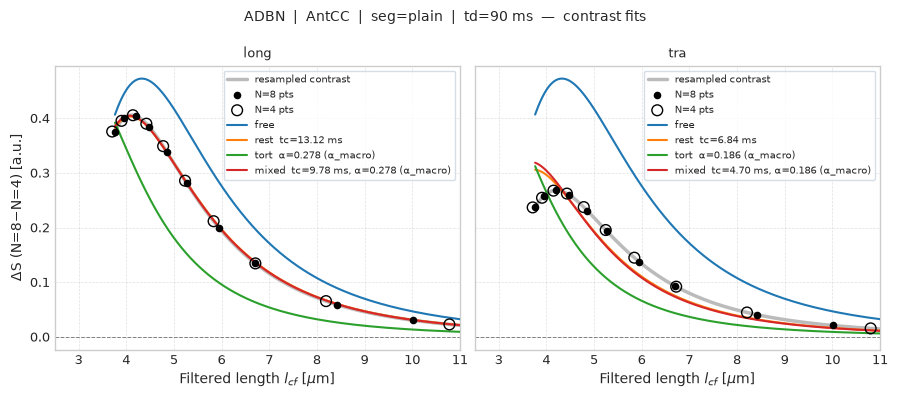

In [7]:
PREVIEW_VARIANT, PREVIEW_SUBJECT, PREVIEW_SHEET, PREVIEW_ROI, PREVIEW_DIRECTION, PREVIEW_TD = next(iter(fit_store))

fig = plot_contrast_model_overlap(
    PREVIEW_VARIANT, PREVIEW_SUBJECT, PREVIEW_SHEET, PREVIEW_ROI, PREVIEW_TD, output_path=None
)
plt.show()


## 8. Batch export

Saves every `(segmentation, subject, sheet, ROI, td)` combination left after the filters in
the config cell to `OUTPUT_DIR` as matched PNG+PDF pairs (`save_figure_formats`). Gated
behind `SAVE_OUTPUTS`.


In [8]:
if SAVE_OUTPUTS:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    combos = sorted({
        (variant, subj, sheet, roi, td_ms)
        for variant, subj, sheet, roi, _direction, td_ms in fit_store
    })
    for i, (variant, subj, sheet, roi, td_ms) in enumerate(combos, start=1):
        fig = plot_contrast_model_overlap(
            variant, subj, sheet, roi, td_ms,
            output_path=OUTPUT_DIR / f'contrast_fit_{subj}_{roi}_{variant}_{sheet}_{td_ms:.0f}',
        )
        plt.close(fig)
        if i % 25 == 0 or i == len(combos):
            print(f'  saved {i}/{len(combos)}')
    print(f'Done: {len(combos)} figures written to {OUTPUT_DIR}')
else:
    print('SAVE_OUTPUTS is False -- skipping batch export.')


  saved 25/125
  saved 50/125
  saved 75/125
  saved 100/125
  saved 125/125
Done: 125 figures written to /mnt/c/Users/ignacio/docs/GitHub/Project-Balseiro-Microstructure/repos/signal_analysis/notebooks/outputs/contrast_models_overlap/resample-ogse_rest_rician/brains/den_gr-topup/plain/lcf/alpha_macro


## 9. Output layout

```
notebooks/outputs/contrast_models_overlap/<DATASET>/<dwi_level>/<alpha_fit|alpha_macro>/
    contrast_fit_<subj>_<roi>_<segmentation>_<sheet>_<td>.png
    contrast_fit_<subj>_<roi>_<segmentation>_<sheet>_<td>.pdf
```

One PNG+PDF pair per `(segmentation, subject, sheet, ROI, td)` combination that survived the
filters in the quick-selection cell, covering every direction present for that combination
in one figure (one panel per direction, as in the preview above). The last folder level is
`alpha_fit` or `alpha_macro` depending on `ALPHA_MODE`, so re-running with the other mode
never overwrites the first set of figures.
